In [1]:
import pandas as pd
import xgboost
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
raw = pd.read_csv('/home/thanhfvux/hustleFlowModel/data/raw/train/train_raw.csv')
raw_test = pd.read_csv('/home/thanhfvux/hustleFlowModel/data/raw/test/test_raw.csv')

In [3]:
raw['PerformanceRating'].unique()

raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     960 non-null    object
 1   Age                           960 non-null    int64 
 2   Gender                        960 non-null    object
 3   EducationBackground           960 non-null    object
 4   MaritalStatus                 960 non-null    object
 5   EmpDepartment                 960 non-null    object
 6   EmpJobRole                    960 non-null    object
 7   BusinessTravelFrequency       960 non-null    object
 8   DistanceFromHome              960 non-null    int64 
 9   EmpEducationLevel             960 non-null    int64 
 10  EmpEnvironmentSatisfaction    960 non-null    int64 
 11  EmpHourlyRate                 960 non-null    int64 
 12  EmpJobInvolvement             960 non-null    int64 
 13  EmpJobLevel         

In [4]:
num_cols = raw.select_dtypes(include="number").columns.tolist()
cat_cols = raw.select_dtypes(include="object").columns.tolist()

print(num_cols)

print(cat_cols)

['Age', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'PerformanceRating']
['EmpNumber', 'Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition']


In [5]:
num_cols.remove("PerformanceRating")

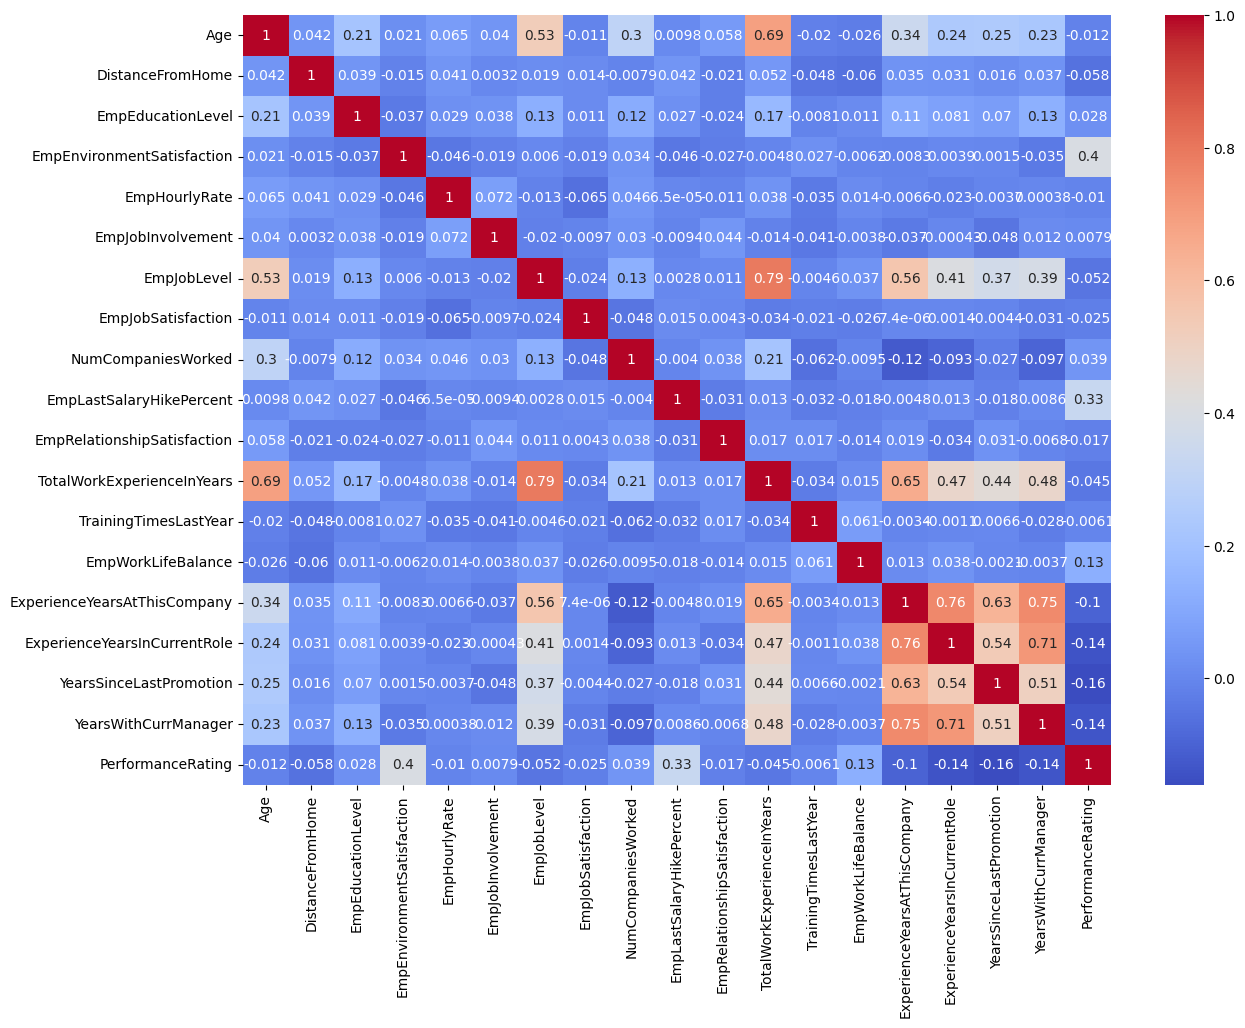

In [6]:
plt.figure(figsize=(14,10))
corr = raw[num_cols + ["PerformanceRating"]].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

## Feature Engineering (FE) 


**Main FE groups:**
- **Ratios / rates**: better represent “stability, tenure, growth speed” than raw columns  
  (e.g., `YearsAtCompany/TotalExp`, `JobLevel/TotalExp`, `CompaniesWorked/TotalExp`).
- **Threshold flags**: capture important milestones  
  (e.g., `YearsSinceLastPromotion==0`, or `>= k`).
- **Satisfaction aggregates (`sat_cols`)**: combine environment/job/relationship/work-life into `mean` or `min` to reduce noise and highlight bottlenecks.



In [7]:

eps = 1e-6

raw = raw.copy()

raw["TenureRatio"] = raw["ExperienceYearsAtThisCompany"] / (raw["TotalWorkExperienceInYears"] + eps)
raw["RoleTenureRatio"] = raw["ExperienceYearsInCurrentRole"] / (raw["ExperienceYearsAtThisCompany"] + eps)
raw["ManagerTenureRatio"] = raw["YearsWithCurrManager"] / (raw["ExperienceYearsAtThisCompany"] + eps)

raw["PromotionRecencyFlag"] = (raw["YearsSinceLastPromotion"] == 0).astype(int)
raw["JobHopRate"] = raw["NumCompaniesWorked"] / (raw["TotalWorkExperienceInYears"] + 1)

raw["ExperienceStartAge"] = raw["Age"] - raw["TotalWorkExperienceInYears"]
raw["JobLevelPerExp"] = raw["EmpJobLevel"] / (raw["TotalWorkExperienceInYears"] + 1)

sat_cols = [
    "EmpEnvironmentSatisfaction",
    "EmpJobSatisfaction",
    "EmpRelationshipSatisfaction",
    "EmpWorkLifeBalance",
]
raw["SatisfactionMean"] = raw[sat_cols].mean(axis=1)
raw["SatisfactionMin"] = raw[sat_cols].min(axis=1)

raw["HourlyRate_log"] = np.log1p(raw["EmpHourlyRate"])


In [8]:

raw_test = raw_test.copy()

raw_test["TenureRatio"] = raw_test["ExperienceYearsAtThisCompany"] / (raw_test["TotalWorkExperienceInYears"] + eps)
raw_test["RoleTenureRatio"] = raw_test["ExperienceYearsInCurrentRole"] / (raw_test["ExperienceYearsAtThisCompany"] + eps)
raw_test["ManagerTenureRatio"] = raw_test["YearsWithCurrManager"] / (raw_test["ExperienceYearsAtThisCompany"] + eps)

raw_test["PromotionRecencyFlag"] = (raw_test["YearsSinceLastPromotion"] == 0).astype(int)
raw_test["JobHopRate"] = raw_test["NumCompaniesWorked"] / (raw_test["TotalWorkExperienceInYears"] + 1)

raw_test["ExperienceStartAge"] = raw_test["Age"] - raw_test["TotalWorkExperienceInYears"]
raw_test["JobLevelPerExp"] = raw_test["EmpJobLevel"] / (raw_test["TotalWorkExperienceInYears"] + 1)

sat_cols = [
    "EmpEnvironmentSatisfaction",
    "EmpJobSatisfaction",
    "EmpRelationshipSatisfaction",
    "EmpWorkLifeBalance",
]
raw_test["SatisfactionMean"] = raw_test[sat_cols].mean(axis=1)
raw_test["SatisfactionMin"] = raw_test[sat_cols].min(axis=1)

raw_test["HourlyRate_log"] = np.log1p(raw_test["EmpHourlyRate"])


In [9]:
print(raw.head())

  EmpNumber  Age  Gender EducationBackground MaritalStatus  \
0  E1001785   28    Male       Life Sciences        Single   
1   E100805   25  Female       Life Sciences        Single   
2  E1001581   25  Female             Medical        Single   
3  E1002027   31    Male    Technical Degree       Married   
4   E100786   30    Male    Technical Degree       Married   

            EmpDepartment            EmpJobRole BusinessTravelFrequency  \
0                   Sales       Sales Executive       Travel_Frequently   
1                   Sales       Sales Executive           Travel_Rarely   
2  Research & Development    Research Scientist           Travel_Rarely   
3                   Sales       Sales Executive           Travel_Rarely   
4                   Sales  Sales Representative           Travel_Rarely   

   DistanceFromHome  EmpEducationLevel  ...  TenureRatio  RoleTenureRatio  \
0                 7                  3  ...     0.800000              0.5   
1                 4   

## ENCODER

## -> re-created num_cols because of adding features that FEATURE ENGINEERED

In [10]:
num_cols = raw.select_dtypes(include="number").columns.tolist()

In [11]:
raw[num_cols].columns


Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceRating', 'TenureRatio',
       'RoleTenureRatio', 'ManagerTenureRatio', 'PromotionRecencyFlag',
       'JobHopRate', 'ExperienceStartAge', 'JobLevelPerExp',
       'SatisfactionMean', 'SatisfactionMin', 'HourlyRate_log'],
      dtype='object')

In [12]:
cat_cols.remove('EmpNumber')

In [13]:

raw[cat_cols].columns

Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object')

In [14]:
raw['PerformanceRating'].unique()

array([1, 0, 2])

In [15]:
ifddf

NameError: name 'ifddf' is not defined

In [16]:
X_train = raw.drop(columns=['PerformanceRating','EmpNumber'])
y_train = raw['PerformanceRating']
X_test = raw_test.drop(columns=['PerformanceRating','EmpNumber'])
y_test = raw_test['PerformanceRating']

In [17]:

num_cols_2 = X_train.select_dtypes(include="number").columns.tolist()
cat_cols_2 = X_train.select_dtypes(exclude="number").columns.tolist()

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier



preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols_2),
    ("cat",OneHotEncoder(handle_unknown="ignore"), cat_cols_2)
    
])

model = Pipeline([
    ("prep",preprocess),
    ("xgb",XGBClassifier(    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    n_estimators=600,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    reg_alpha=0.1,
    random_state=42))
])

In [22]:
model.fit(X_train,y_train)

pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, f1_score, classification_report


acc = accuracy_score(y_test, pred)
f1_macro = f1_score(y_test, pred, average="macro")

classification_check = classification_report(y_test, pred, digits = 4)

print("Accuracy:", acc)
print("F1 macro:", f1_macro)

print("\nClassification report:",classification_check )


Accuracy: 0.925
F1 macro: 0.8796825396825397

Classification report:               precision    recall  f1-score   support

           0     0.8889    0.8205    0.8533        39
           1     0.9341    0.9714    0.9524       175
           2     0.9091    0.7692    0.8333        26

    accuracy                         0.9250       240
   macro avg     0.9107    0.8537    0.8797       240
weighted avg     0.9240    0.9250    0.9234       240



In [24]:
from sklearn.metrics import get_scorer_names
print(sorted(get_scorer_names()))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [25]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

res = cross_validate(
    model,
    X_train, y_train,
    cv=cv,
    scoring={"f1_macro": "f1_macro", "acc": "accuracy"},
    return_train_score=True
)

print("Train F1-macro mean:", res["train_f1_macro"].mean())
print("Val   F1-macro mean:", res["test_f1_macro"].mean())
print("Train Acc mean:", res["train_acc"].mean())
print("Val   Acc mean:", res["test_acc"].mean())


Train F1-macro mean: 0.9712384388935767
Val   F1-macro mean: 0.8794919318995206
Train Acc mean: 0.9809895833333334
Val   Acc mean: 0.9229166666666666
